In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')

warnings.filterwarnings('ignore')

# **Outliers**

Outliers are data points that deviate significantly from the majority of observations. These are most commonly associated with numerical columns because numerical data is measurable and can be ordered. Outliers are often identified using statistical methods (e.g., mean, standard deviation) or visualization tools.

## **Examples of Outliers**
- **House Prices**: In a dataset of house prices, a value like $1,000,000 in a group of homes worth $100,000 would be an outlier.  
- **Age Data**: An age of 150 in a dataset of human ages is an obvious outlier.  

---

## **Common Methods for Handling Numerical Outliers**

### 1. **Removal**
- **What It Does**: Excludes outlier observations from the dataset.  
- **When to Use**: When outliers are caused by data entry errors or provide no meaningful information.

---

### 2. **Imputation**
- **What It Does**: Replaces outlier values with a central measure (e.g., mean or median).  
- **When to Use**: When outliers are valid but their effect needs to be moderated.

---

### 3. **Transformation**
- **What It Does**: Applies transformations (e.g., logarithm, square root) to reduce the impact of outliers.  
- **When to Use**: When data is skewed due to extreme outliers.

---

### 4. **Winsorizing**
- **What It Does**: Caps extreme values at specific percentiles (e.g., replaces the lowest and highest values with those at the 1st and 99th percentiles).  
- **When to Use**: When extreme values are part of the data but need moderation.

---

### 5. **Z-Score Method**
- **What It Does**: Identifies outliers as points that are a specific number of standard deviations away from the mean (e.g., above 3 or below -3).  
- **When to Use**: For normally distributed data.

---

### 6. **Interquartile Range (IQR) Method**
- **What It Does**: Identifies outliers as values below 𝑄1−1.5×IQR or above 𝑄3+1.5×IQR.  
- **When to Use**: For skewed distributions.

---

## **Common Methods for Handling Categorical Outliers**

### 1. **Grouping**
- **What It Does**: Combines rare categories into an "Other" category.  
- **When to Use**: When certain categories represent a small fraction of the dataset.

---

### 2. **Removal**
- **What It Does**: Excludes observations with rare categories that do not add value.  
- **When to Use**: When the outlier category is poorly represented.

---

### 3. **Re-coding**
- **What It Does**: Reassigns rare categories based on domain knowledge.  
- **When to Use**: To better fit the context of the analysis.

---

## **Tips for Identifying Outliers**
Use visual tools such as:  
- **Histograms**: To observe the data distribution.  
- **Box Plots**: To detect extreme values.  
- **Scatter Plots**: To identify outliers in relationships between variables.


In [24]:
df = pd.read_csv(r'WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [25]:
# No null values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [26]:
# No duplicated rows
df.duplicated().sum()

0

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


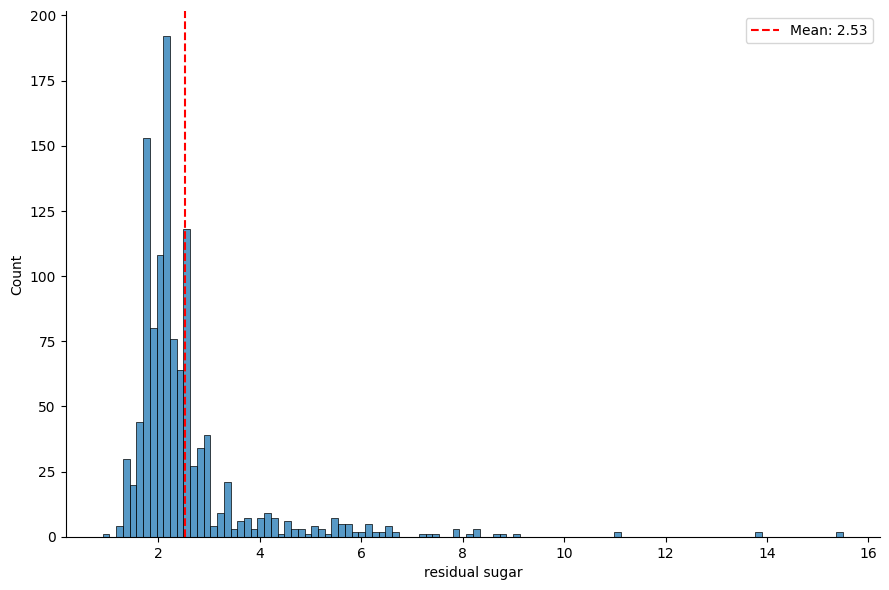

In [28]:
sns.displot(df['residual sugar'], height = 6, aspect = 1.5, edgecolor = 'black')
mean = np.mean(df['residual sugar'])
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
plt.legend()

<Axes: ylabel='residual sugar'>

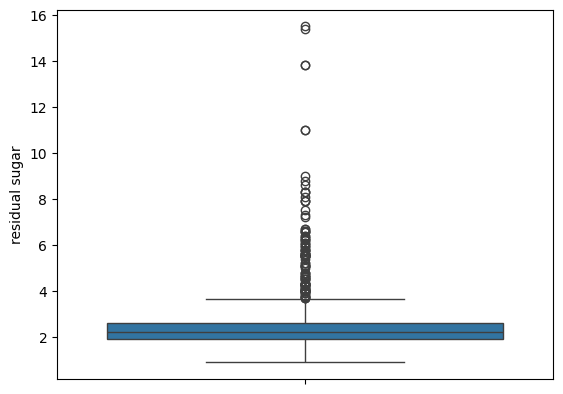

In [29]:
# Use boxplot to see outliers clearly
sns.boxplot(df['residual sugar'])

<hr>

# **Explanation of This Boxplot**

- **Box**: The blue box represents the **interquartile range (IQR)**, which is the middle 50% of the data. The bottom and top edges of the box correspond to the first quartile (**Q1**) and third quartile (**Q3**), respectively.

- **Line in the Box (Median)**: The line inside the box is the median (**Q2**) of the data, representing the middle value.

- **Whiskers**: The lines extending from the box (whiskers) show the range of the data within **1.5 times the IQR** from the quartiles. This range typically captures most of the data points that aren't considered outliers.

- **Outliers**: The dots beyond the whiskers represent **outliers**, which are values that fall outside of the 1.5 times IQR range. In this case, there are many outliers above the upper whisker, indicating that some data points have significantly higher values of residual sugar compared to the majority of the data.

<hr>

## **What are Quartiles (Q1, Q2, Q3)?**
### When you have a dataset, quartiles are simply numbers that divide your data into four equal parts.

### **Q1 (First Quartile):**
- This is the value that separates the lowest 25% of the data from the rest. So, 25% of the data points fall below Q1. It's also known as the 25th percentile.

### **Q2 (Second Quartile or Median):**
- The second quartile is also the median of the dataset. It divides the data into two equal halves, where 50% of the data points fall below Q2. This is also called the 50th percentile.

### **Q3 (Third Quartile):**
- Q3 is the value that separates the lowest 75% of the data from the upper 25%. It indicates that 75% of the data falls below this point. This is also called the 75th percentile.

### **Interquartile Range (IQR):**
- The IQR is a measure of statistical dispersion and is calculated as the difference between Q3 and Q1. In formula:<br>
  ***IQR = Q3 - Q1***<br>
  It shows the range within which the middle 50% of the data lies. IQR is often used to detect outliers in the data.<br>

### **Outliers:**
- Any value that is significantly higher or lower than the majority of the data is considered an outlier. Typically, outliers are defined as values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

### The lower boundary is:
    - Lower Bound = Q1 - 1.5 * IQR

### The upper boundary is:
    - Upper Bound = Q3 + 1.5 * IQR

### **Visualizing Quartiles in a Box Plot:**
- In a box plot, the box represents the IQR. The line inside the box shows the median (Q2), and the "whiskers" extend to 1.5 times the IQR. Outliers appear as individual points beyond the whiskers.

<hr>

## **Z-Score**
- **The Z-score, also known as the standard score, measures how many standard deviations a data point is from the mean of the dataset. It’s a simple and effective way to understand the relative position of any given data point within a dataset.**<br>

## **Z-Score Equation**
    Z = (X − μ) / σ​

    - Z is the Z-score.
    - X is the value of the data point.
    - μ is the mean of the dataset.
    - σ is the standard deviation of the dataset.

## **Understanding the Z-score:**
    z = 0: The data point is exactly at the mean.
    z > 0: The data point is above the mean.
    z < 0: The data point is below the mean.
    |z| > 3: Typically considered an outlier (assuming normal distribution).


<br>

![Normal Distribution](./Images/Normal_Distribution.jpg)

##### **A normal distribution is shown above and it is estimated that 68% of the data points lie<br>between +/- 1 standard deviation. 95% of the data points lie between +/- 2 standard<br>deviation 99.7% of the data points lie between +/- 3 standard deviation**

##### **If the z score of a data point is more than 3, it indicates that the data point is quite<br> different from the other data points. Such a data point can be an outlier.**

##### **For example, in a survey, it was asked how many children a person had. Suppose the data obtained from people is:<br>[1, 2, 2, 2, 3, 1, 1, 15, 2, 2, 2, 3, 1, 1, 2]**
##### **Clearly, 15 is an outlier in this dataset.**

<hr>

# **Outlier Detection Methods**

## 1. **Mean-Standard Deviation Method (with Z-scores)**
- **Z-score Formula**:  
  $$
  z = \frac{x - \mu}{\sigma}
  $$

- **Upper Bound**:  
  $$
  \text{Upper Bound} = \mu + 3 \times \sigma
  $$

- **Lower Bound**:  
  $$
  \text{Lower Bound} = \mu - 3 \times \sigma
  $$

---

## 2. **Interquartile Range (IQR) Method**
- **IQR Formula**:  
  $$
  \text{IQR} = Q3 - Q1
  $$

- **Upper Bound**:  
  $$
  \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}
  $$

- **Lower Bound**:  
  $$
  \text{Lower Bound} = Q1 - 1.5 \times \text{IQR}
  $$

---

### **Key Differences**
- The **Mean-Standard Deviation Method** relies on the mean ($\mu$) and standard deviation ($\sigma$) and works best for **normally distributed data**.
- The **IQR Method** uses quartiles ($Q1$, $Q3$) and is more robust for **skewed or non-normal data**.

Choose the method based on the characteristics and distribution of your dataset.


In [30]:
data = [1, 2, 2, 2, 3, 1, 1, 15, 2, 2, 2, 3, 1, 1, 2]
data_mean = np.mean(data)
data_std = np.std(data)

print('Mean of the dataset is: ', data_mean)
print('std of the data set is:', data_std)

Mean of the dataset is:  2.6666666666666665
std of the data set is: 3.3598941782277745


In [31]:
# Z-Score Using Pandas Library
threshold = 3
outliers = []

for data_point in data:
    z = (data_point - data_mean) / data_std
    if z > threshold:
        outliers.append(data_point)
print('outliers in dataset is: ', outliers)

outliers in dataset is:  [15]


## **Z-Score in Python: Libraries and Implementation**

In [32]:
# Z-Score Using scipy Library
import numpy as np
from scipy import stats

data = np.array([10, 20, 30, 40, 50])

Z_Score = stats.zscore(data)
print(Z_Score)

[-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


![Normal Distribution](./Images/Z_Score.jpg)

<Axes: ylabel='residual sugar'>

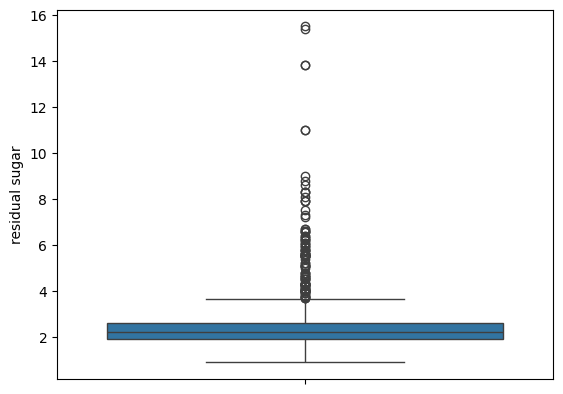

In [33]:
sns.boxplot(df['residual sugar'])

In [34]:
# Calculate Limits based on Interquartile Range (IQR) Method
# Preferred when the data is not normally distributed or contains outliers.

Q1 = df['residual sugar'].quantile(0.25)
Q3 = df['residual sugar'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print(f'Upper Limit: {upper_limit}')
print(f'Upper Limit: {lower_limit}')

# Find the Outliers
df.loc[(df['residual sugar'] > upper_limit) | (df['residual sugar'] < lower_limit)].head()

Upper Limit: 3.6500000000000004
Upper Limit: 0.8499999999999996


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
25,7.8,0.645,0.00,5.50,0.086,5.0,18.0,0.9986,3.40,0.55,9.6,6,35
28,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,40
45,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,64
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,65
106,7.1,0.430,0.42,5.50,0.071,28.0,128.0,0.9973,3.42,0.71,10.5,5,155


data shape before deleting outliers:  (1143, 13)
data shape after  deleting outliers:  (1033, 13)
len of Outliers in "residual sugar" Feature:  110


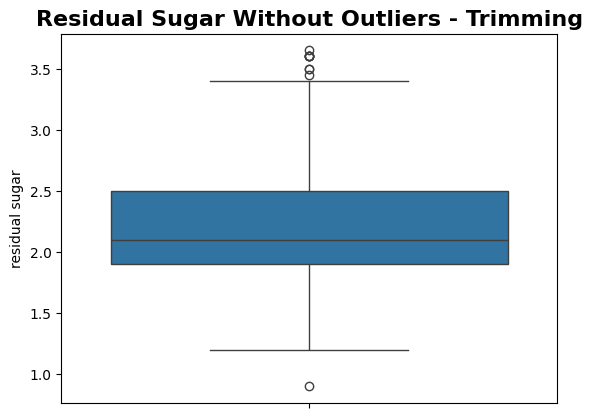

In [36]:
# trimming - delete the outlier data
df_after_trimming = df.loc[(df['residual sugar'] < upper_limit) & (df['residual sugar'] > lower_limit)]

print('data shape before deleting outliers: ', df.shape)
print('data shape after  deleting outliers: ', df_after_trimming.shape)
print('len of Outliers in \"residual sugar\" Feature: ', df.shape[0] - df_after_trimming.shape[0])

# Box Plot for Residual Sugar After Deleting Outliers in Trimming Way
sns.boxplot(df_after_trimming['residual sugar'])
plt.title('Residual Sugar Without Outliers - Trimming', fontsize = 16, fontweight = 'bold')
plt.show()

min value:  0.9
max value:  3.6500000000000004


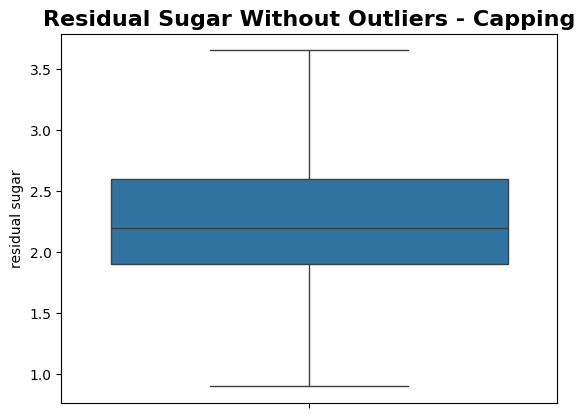

In [37]:
# capping - change the outliers values to upper or lower limit values

df_after_capping = df.copy()

df_after_capping.loc[df_after_capping['residual sugar'] > upper_limit, 'residual sugar'] = upper_limit
df_after_capping.loc[df_after_capping['residual sugar'] < lower_limit, 'residual sugar'] = lower_limit

print('min value: ', df_after_capping['residual sugar'].min())
print('max value: ', df_after_capping['residual sugar'].max())

# Box Plot for Residual Sugar After Capping Outliers
sns.boxplot(df_after_capping['residual sugar'])
plt.title('Residual Sugar Without Outliers - Capping', fontsize = 16, fontweight = 'bold')
plt.show()